# Exercises and Self Study on Link Prediction with Graph Neural Networks

This notebook contains some very basic experiments and demos with GNNs in Pytorch geometric. The convolution class is adapted from https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html where we define our convolutions as a subclass of message passing networks.

Instead, you can also use an existing implementation of convolution layer from torch geometric. You can take an inspiration at https://pytorch-geometric.readthedocs.io/en/latest/notes/introduction.html

In [1]:
import numpy as np
import math
import networkx as ntx

import torch
import torch.nn as nn
from torch.nn import Linear, Parameter
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing,global_add_pool
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import from_networkx, add_self_loops, degree

from torch_geometric.datasets import Planetoid

import matplotlib.pyplot as plt

import random # library for randomly sampling from data

/home/toita86/Documents/AAU/ML/self-study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        # can be changed to other
        # you can also experiment here with generalized aggregation operator
        super().__init__(aggr='add')  # "Add" aggregation (Step 5). flow="source_to_target"
        # linear transformation
        self.lin = Linear(in_channels, out_channels, bias=False)

        # nonlinearity - now ReLU, experiment with the other

        self.nonlin = nn.ReLU()
        # I have commented bias here, but you can play with this
        # in order to use it, you also need to uncomment the message method and the bias line in the forward method
        #self.bias = Parameter(torch.empty(out_channels))

        #self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        #self.bias.data.zero_()

    # we will use a feature vector and a graph represented as edge index as input parameters for forward pass in convolutional layer
    # please note, that normalization is commented for now. Please experiment with this
    def forward(self, x, edge_index):
        # x has shape [N, in_channels]
        # edge_index has shape [2, E]

        # Step 1: Add self-loops to the adjacency matrix.
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Step 2: Linearly transform node feature matrix.
        x = self.lin(x)

        # Step 3: Compute normalization.
        #row, col = edge_index
        #deg = degree(col, x.size(0), dtype=x.dtype)
        #deg_inv_sqrt = deg.pow(-0.5)
        #deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        #norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # running nonlinearity over the embeddings
        
        x = self.nonlin(x)
        
        # Step 4-5: Start propagating messages.
        #out = self.propagate(edge_index, x=x, norm=norm)

       
        
        out = self.propagate(edge_index, x=x)

        # Step 6: Apply a final bias vector.
        #out = out + self.bias

        return out

    #def message(self, x_j, norm):
        # x_j has shape [E, out_channels]

        # Step 4: Normalize node features.
     #   return norm.view(-1, 1) * x_j

In [3]:
class MyGnn(nn.Module):
    # we will have as many convolutions layers as first len(dims) - 2 input parameters
    # This means for example, that if I want to have 3 convolution layers, I need to pass 5 input parameters
    # The first 3 will be used for defining dimmensionality for convolution layers and the last two will be defining the last linear layer
    def __init__(self,dims):
        super().__init__()
        # initialize
        self.layers=torch.nn.ModuleList()

        #print(len(dims))
        #print(dims[len(dims)-2])
        # create message passing layers
        for d in range(len(dims)-2):
            self.layers.append(GCNConv(dims[d],dims[d+1]))
        # add a final linear transformation (this one also including a bias vector)
        # see also the generalized set pooling where MLP was used as a generalized aggregator
        self.layers.append(nn.Linear(dims[-2],dims[-1],bias=True))
        # adding a sigmoid activation at the end.
        self.layers.append(nn.Sigmoid())

    # we will use feature vector and graph as an input for forward pass
    def forward(self,x,graph,batch):
        h=x
        for i in range(len(self.layers)):
            l=self.layers[i]  
            if type(l)==GCNConv:
                h=l.forward(h,graph)
            else:
                h=l.forward(h)

        # instead of returning the output vector, a dot product is returned which gives a similarity in the embedding space between nodes
        # this is our final step as a link predictor
        dot_pr = torch.matmul(h, torch.transpose(h, 0, 1))
        #print(dot_pr)
        
        return dot_pr

    
            
    def init(self):
        for i in range(len(self.layers)):
            l=self.layers[i] 
            if type(l)==MyConv:
                l.init()
            if type(l)==nn.Linear:
                l.weight.data.uniform_(-1,1)
                l.bias.data.uniform_(-1,1)
        
    def showParameters(self):
        for name, param in self.named_parameters():
            print("Parameter {} : \n {}".format(name, param.data))

We will construct node features out of node atrubutes. We will have two dimmensional feature vector, with first dimmension refering to the club Officers and the second dimmension refering to the club Mr. Hi. In each case, if a node is in one club, it will have value 1 there.


<font color='red'>Please note, that you can also experiment with randomly initialized vector of coordinates. In that case, we would not use 
any attribute or feature from the content, and the only information we will be able to utilize in learning is the graph structure. You can
experiment with it in the exercises too.</font>

In [4]:
random.seed(0)
torch.manual_seed(0)

zachary = ntx.karate_club_graph() #importing karate club network
sampled_edges = random.sample(list(zachary.edges), round(0.2*zachary.number_of_edges()))
print(sampled_edges)
# remove those sampled edges
for u, v in sampled_edges:
    zachary.remove_edge(u, v)

[(15, 33), (20, 32), (0, 6), (3, 12), (25, 31), (24, 25), (18, 33), (5, 10), (23, 33), (13, 33), (2, 9), (24, 31), (1, 3), (4, 10), (30, 32), (15, 32)]


Here we can see how nodes are assigned to a karate club.

In [5]:
for n in zachary.nodes():
    print("Node " + str(n) + ". " + zachary.nodes[n]['club'])

Node 0. Mr. Hi
Node 1. Mr. Hi
Node 2. Mr. Hi
Node 3. Mr. Hi
Node 4. Mr. Hi
Node 5. Mr. Hi
Node 6. Mr. Hi
Node 7. Mr. Hi
Node 8. Mr. Hi
Node 9. Officer
Node 10. Mr. Hi
Node 11. Mr. Hi
Node 12. Mr. Hi
Node 13. Mr. Hi
Node 14. Officer
Node 15. Officer
Node 16. Mr. Hi
Node 17. Mr. Hi
Node 18. Officer
Node 19. Mr. Hi
Node 20. Officer
Node 21. Mr. Hi
Node 22. Officer
Node 23. Officer
Node 24. Officer
Node 25. Officer
Node 26. Officer
Node 27. Officer
Node 28. Officer
Node 29. Officer
Node 30. Officer
Node 31. Officer
Node 32. Officer
Node 33. Officer


We construct a feature vector for each node and create a dictionary for the labels in the drawing function

In [6]:
Y=np.array(list(1.0  if zachary.nodes[n]["club"]=="Officer" else 0.0 for n in zachary.nodes()))

labels = []
officers = list(1.0  if zachary.nodes[n]["club"]=="Officer" else 0.0 for n in zachary.nodes())
mr_hi = list(0.0  if zachary.nodes[n]["club"]=="Officer" else 1.0 for n in zachary.nodes())
features = list(zip(officers, mr_hi))
print(features)

features_dict = {index: value for index, value in enumerate(features)}
print(features_dict)

[(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (1.0, 0.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (1.0, 0.0), (1.0, 0.0), (0.0, 1.0), (0.0, 1.0), (1.0, 0.0), (0.0, 1.0), (1.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0), (1.0, 0.0)]
{0: (0.0, 1.0), 1: (0.0, 1.0), 2: (0.0, 1.0), 3: (0.0, 1.0), 4: (0.0, 1.0), 5: (0.0, 1.0), 6: (0.0, 1.0), 7: (0.0, 1.0), 8: (0.0, 1.0), 9: (1.0, 0.0), 10: (0.0, 1.0), 11: (0.0, 1.0), 12: (0.0, 1.0), 13: (0.0, 1.0), 14: (1.0, 0.0), 15: (1.0, 0.0), 16: (0.0, 1.0), 17: (0.0, 1.0), 18: (1.0, 0.0), 19: (0.0, 1.0), 20: (1.0, 0.0), 21: (0.0, 1.0), 22: (1.0, 0.0), 23: (1.0, 0.0), 24: (1.0, 0.0), 25: (1.0, 0.0), 26: (1.0, 0.0), 27: (1.0, 0.0), 28: (1.0, 0.0), 29: (1.0, 0.0), 30: (1.0, 0.0), 31: (1.0, 0.0), 32: (1.0, 0.0), 33: (1.0, 0.0)}


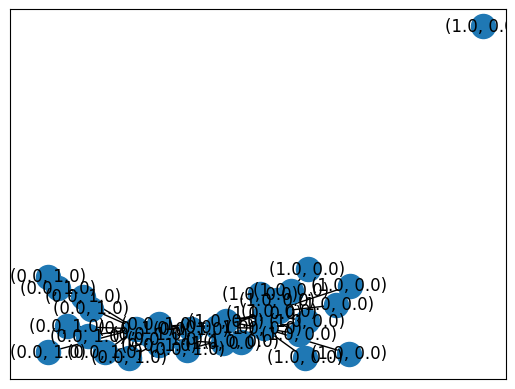

In [7]:
#ntx.draw_kamada_kawai(zachary, with_labels=True, labels=labels_dict)
ntx.draw_networkx(zachary, with_labels=True, labels=features_dict)

In [8]:
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)
x = torch.tensor([[0,1], [1,0], [1,1]], dtype=torch.float)
print(x)

tensor([[0., 1.],
        [1., 0.],
        [1., 1.]])


In [9]:
conv = GCNConv(2, 2)
x = conv(x, edge_index)
print(x)

tensor([[0.3793, 0.0000],
        [0.7534, 0.0000],
        [0.3740, 0.0000]], grad_fn=<ScatterAddBackward0>)


In [10]:
#conv.reset_parameters()

In [11]:
torch_graph_zachary = from_networkx(zachary)
conv_zachary = GCNConv(2, 2)
features_torch = torch.tensor(features)
print(features_torch)
print(torch_graph_zachary['edge_index'])
# features_torch = conv_zachary(features_torch, torch_graph_zachary['edge_index'])
print(features_torch)

tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]])
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,
          1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
          4,  4,  5,  5,  5,  6,  6,  6,  7,  7,  7,  7,  8,  8,  8,  8,  8,  9,
         10, 11, 12, 13, 13, 13, 13, 14, 14, 16, 16, 17, 17, 18, 19, 19, 19, 20,
         21, 21, 22, 22, 23, 23, 23, 23, 24, 25, 26, 26, 27, 27

We are going to train the GNN now.

In [12]:
# Needed for dividing the nodes into (training) batches. For now, 
# we just create a single batch
batch=torch.zeros(features_torch.size()[0],dtype=torch.long)

Now we should learn the weights and hopefully improve the prediction

Creating a GNN where
dimension of initial node features = 2 - this is from our zachary feature vector
one message passing layer transforming into representation size 3
one linear layer mapping to output dimension 2 (because we want to have a feature vector with at such domensionality learned)
Note, that output is a similarity matrix since we do at the end a dot product between each single node representation.

In [13]:
# for now, there is one convolution layer and one linear layer. The one convolution layer makes sure that the local neighbourhood is added
# experiment with the number of convolution layers - this will expand the neighborhood considered and will impact the accuracy as well
# experiment also with nonlinearity and also with number of hidden features in internal layers.

gnn=MyGnn([2,3,2])

optimizer = torch.optim.Adam(gnn.parameters(),lr=0.001)
# Mean square error used as a loss function here. You can experiment with different loss functions - see lecture 8 for several pairwise loss functions
loss=nn.MSELoss(reduction='mean')

# note that after 200 epochs the error can still be relatively large
epochs = 200

A=ntx.adjacency_matrix(zachary).todense()
O=np.ones(A.shape)
Abin=np.minimum(A,O)



target = torch.tensor(Abin)

for epoch in range(epochs):
    epochloss=0
    #for batch in loader:
    optimizer.zero_grad()
    # forward pass in our GNN with convolution layer(s)
    out = gnn(features_torch,torch_graph_zachary['edge_index'], batch)
    #out_torch = torch.tensor(out)
    #target = batch.y
    l = loss(out,target.float())

    epochloss+=l.detach().item()
    l.backward()
    optimizer.step()
    print("Epoch: {}  Loss: {}  ".format(epoch,epochloss) )
#print("Epoch: {}  Loss: {}  ".format(epoch,epochloss) )

Epoch: 0  Loss: 0.44758865237236023  
Epoch: 1  Loss: 0.44657808542251587  
Epoch: 2  Loss: 0.44557201862335205  
Epoch: 3  Loss: 0.4445704221725464  
Epoch: 4  Loss: 0.44357332587242126  
Epoch: 5  Loss: 0.4425809681415558  
Epoch: 6  Loss: 0.44159331917762756  
Epoch: 7  Loss: 0.440610408782959  
Epoch: 8  Loss: 0.43963220715522766  
Epoch: 9  Loss: 0.4386588931083679  
Epoch: 10  Loss: 0.43769046664237976  
Epoch: 11  Loss: 0.4367270767688751  
Epoch: 12  Loss: 0.4357684552669525  
Epoch: 13  Loss: 0.4348149001598358  
Epoch: 14  Loss: 0.43386632204055786  
Epoch: 15  Loss: 0.432922899723053  
Epoch: 16  Loss: 0.4319845139980316  
Epoch: 17  Loss: 0.4310511648654938  
Epoch: 18  Loss: 0.43012285232543945  
Epoch: 19  Loss: 0.42919978499412537  
Epoch: 20  Loss: 0.4282817542552948  
Epoch: 21  Loss: 0.4273688495159149  
Epoch: 22  Loss: 0.4264610707759857  
Epoch: 23  Loss: 0.4255583882331848  
Epoch: 24  Loss: 0.4246608316898346  
Epoch: 25  Loss: 0.42376837134361267  
Epoch: 26  Lo

In [14]:
out_matr = out.detach().numpy()

In [15]:
print(out_matr)

[[0.5342079  0.5131923  0.51055384 ... 0.49579152 0.4982059  0.4982059 ]
 [0.5131923  0.5136058  0.51460993 ... 0.523764   0.52203035 0.52203035]
 [0.51055384 0.51460993 0.516235   ... 0.5294703  0.52702856 0.52702856]
 ...
 [0.49579152 0.523764   0.5294703  ... 0.5695452  0.562446   0.562446  ]
 [0.4982059  0.52203035 0.52702856 ... 0.562446   0.556155   0.556155  ]
 [0.4982059  0.52203035 0.52702856 ... 0.562446   0.556155   0.556155  ]]


Evaluation similarly to the previous cases in last 2 lectures.
You can also run evaluation inside the torch, with dataloader and dateset properties and properly defining batches.
I, for simplicity, detached it from the learned model and evaluated outside as we did until now. If you want to look at how to define batches, please revisit the tutorial at: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html

In [16]:
k = 10 # the size of the list to consider
countHitsdot_pr = 0 # counter for hits VS
for u, v in sampled_edges:
    LinkPredictionListdot_pr = out_matr[u] # extracting list of similar nodes for current node for dot_pr
    sort_indexdot_pr = np.argsort(LinkPredictionListdot_pr) # sorting according to the similarity value for VS
    # finding position of the hidden node (the one where the edge was removed and was supposed to be)
    position_in_the_listdot_pr = list(sort_indexdot_pr).index(v)
    # adding to the counter if in the position which is within top K for each similarity (4 lines)
    if(position_in_the_listdot_pr < k-1): countHitsdot_pr = countHitsdot_pr + 1
#HitRatedot_pr = countHitsdot_pr / zachary.number_of_nodes()
HitRatedot_pr = countHitsdot_pr / len(sampled_edges)
print(HitRatedot_pr)

0.0625


## Exercises and self studies

### Background Knowledge & Implementation Plan

#### Key Concepts for the Exercises

**1. GCN Architecture Components We Can Tune:**
- **Number of Convolution Layers**: Controls receptive field depth (how many hops neighbors contribute)
- **Hidden Dimensions**: Size of feature representations at each layer
- **Aggregation Methods**: How neighborhood information is combined (add, mean, max, etc.)
- **Self-loops**: Whether nodes aggregate their own features (typically improves performance)
- **Normalization**: Degree normalization prevents vanishing/exploding gradients
- **Activation Functions**: ReLU, ELU, GELU, etc. (non-linearity strength)
- **Bias Terms**: Additional learnable parameters per layer
- **Linear Transformations**: Can be toggled in the GCNConv class

**2. Karate Club Dataset:**
- 34 nodes, 78 edges
- 2D feature vector (Officer/Mr. Hi membership)
- ~20% edges removed for testing
- Simple baseline for testing architecture variations

**3. Cora Dataset:**
- 2,708 papers (nodes), 5,429 edges
- 1,433-dimensional feature vectors (word presence)
- 7 paper categories (though not used for link prediction here)
- More realistic dataset for testing scalability

**4. Evaluation Metric:**
- **Hit Rate@K**: Percentage of hidden edges where true target appears in top K predictions
- Measures ranking quality of predicted adjacency scores

#### Implementation Plan

**Phase 1: Karate Club Experiments (Hyperparameter Tuning)**
1. Create a configurable model class that accepts architecture parameters
2. Test variations systematically:
   - Layer depths: [2,3,5] convolution layers
   - Hidden dimensions: [4, 8, 16, 32]
   - Aggregation methods: ['add', 'mean', 'max']
   - Toggle self-loops: True/False
   - Toggle normalization: True/False
   - Activation functions: [ReLU, ELU, GELU]
   - Toggle bias: True/False
3. Track Hit Rate@10 for each configuration
4. Document best performing configurations

**Phase 2: Extend to Cora Dataset**
1. Load Cora graph data (from cora.cites for edges)
2. Extract features from cora.content file:
   - Each line: `<paper_id> <word_1> ... <word_1433> <class_label>`
   - Use 1433-dimensional word feature vectors
3. Split edges (80% train, 20% test)
4. Apply best configurations from Phase 1
5. Compare Hit Rate@K for Karate vs Cora

**Phase 3: Analysis & Reflection**
1. Tabulate results showing impact of each hyperparameter
2. Analyze trade-offs (accuracy vs. training time vs. model size)
3. Compare feature richness effect (2D vs 1433D features)
4. Document observations for exam preparation

#### Metrics to Track
- **Hit Rate@K** (K=10): Primary metric
- **Training Loss**: Convergence behavior
- **Training Time**: Computational efficiency
- **Model Parameters**: Complexity vs. performance trade-off


1. Please experiment with number of aggregation, convolution layers, self-loops, normalization, activation functions, bias, and linear layer. 
See whether you manage also to add some extensions to the basic models, such as some generalized aggregation or update mechanisms. Please note that you have a linear transformation also in the convolution class which you can also switch off. Play with this as well. Please note what is the influence of those on the accuracy.
2. Please extend the experiment to Cora dataset. 
In the karate club dataset we only had one feature: membership of the club. we have constructured a two dimmensional feature vector out of that and used that in the GNN. 
For Cora dataset, you have richer feature set in the cora.content file. Please define your feature vector out of that file and experiment with it.
3. Please note the results from the experimentation and reflect on that. Make notes for the exam.

In [17]:
# Run Phase 1: Karate Club grid search (uses experiments.py)
from experiments import run_karate_search
# features_torch, torch_graph_zachary['edge_index'], sampled_edges are defined earlier in this notebook
results = run_karate_search(features_torch, torch_graph_zachary['edge_index'], sampled_edges, epochs=200, k=10,
                             layer_depths=[2,3,5], hidden_dims=[4,8,16], aggrs=['add','mean'], activations=['relu','elu'],
                             biases=[False, True], self_loops=[True, False], norms=[True, False], lr=1e-3)
# Print top 10 configurations by Hit Rate@10
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1}: HitRate={r['hit_rate']:.3f} depth={r['depth']} hid={r['hidden_dim']} aggr={r['aggr']} act={r['activation']} bias={r['bias']} self_loops={r['self_loops']} norm={r['norm']}")

Rank 1: HitRate=0.875 depth=2 hid=16 aggr=mean act=relu bias=False self_loops=True norm=False
Rank 2: HitRate=0.875 depth=2 hid=16 aggr=mean act=relu bias=True self_loops=True norm=False
Rank 3: HitRate=0.812 depth=2 hid=8 aggr=mean act=relu bias=False self_loops=True norm=False
Rank 4: HitRate=0.812 depth=2 hid=8 aggr=mean act=relu bias=True self_loops=True norm=False
Rank 5: HitRate=0.750 depth=2 hid=4 aggr=add act=elu bias=True self_loops=True norm=True
Rank 6: HitRate=0.750 depth=2 hid=16 aggr=mean act=relu bias=False self_loops=False norm=False
Rank 7: HitRate=0.750 depth=3 hid=16 aggr=mean act=relu bias=False self_loops=False norm=False
Rank 8: HitRate=0.688 depth=2 hid=4 aggr=add act=elu bias=False self_loops=False norm=True
Rank 9: HitRate=0.688 depth=2 hid=8 aggr=add act=relu bias=False self_loops=True norm=True
Rank 10: HitRate=0.688 depth=2 hid=8 aggr=add act=relu bias=False self_loops=False norm=True


**Exam Notes — Interpretation Guide**

- **Metric (HitRate@K):** Fraction of removed edges whose true target appears in the top-K predicted neighbors. Higher is better; K=10 was used here.
- **Top result meaning:** A configuration with HitRate=0.875 recovered 87.5% of hidden edges in top-10 — strong performance on Karate Club (small graph).
- **Hyperparameter effects (how to explain):**
  - **Depth:** More convolution layers increase receptive field (captures farther neighbors) but may over-smooth on tiny graphs.
  - **Hidden dim:** Larger embeddings can encode richer structure but risk overfitting when N is small.
  - **Aggregation (add/mean):** Changes how neighbor messages combine; `add` preserves magnitude of multi-neighbor signals, `mean` normalizes by degree.
  - **Self-loops:** Including self-loops lets nodes keep their own features when aggregating — useful when node attributes matter.
  - **Normalization:** Symmetric degree normalization (GCN-style) stabilizes training on irregular degree distributions.
  - **Bias / Activation:** Minor tuning knobs; report if they consistently improved HitRate.
- **How to present in exam:** State the experimental setup (dataset, hidden-edge split, metric), list top configurations (HitRate and hyperparameters), and draw one or two observations tying hyperparameters to performance with a brief explanation (mechanism).
- **Caveats:** Results on Karate Club do not always transfer to larger graphs (e.g., Cora). Report computational cost (epochs, time) when comparing models.
- **Suggested follow-ups to mention:** Test stability by repeating random edge removals, report mean±std of HitRate; run on Cora to show scaling effects.

In [28]:
# Phase 2: Run top-5 Karate configs on Cora (reduced epochs for speed)
from experiments import run_cora_experiment
# Prepare top-5 configs from the Phase 1 results stored in `results`
best_configs = [
    {'depth': 50, 
     'hidden_dim': 218,
     'aggr': "mean",
     'activation': "relu",
     'bias': True,
     'self_loops': True,
     'norm': True
     },]
# for r in results[:5]:
#     best_configs.append({
#         'depth': r['depth'],
#         'hidden_dim': r['hidden_dim'],
#         'aggr': r['aggr'],
#         'activation': r['activation'],
#         'bias': r['bias'],
#         'self_loops': r['self_loops'],
#         'norm': r['norm']
#     })
# Run on Cora (uses local Planetoid data if available)
cora_results = run_cora_experiment(best_configs, root='/home/toita86/Documents/AAU/ML/data/Planetoid', remove_frac=0.2, epochs=500, k=10, lr=1e-3, seed=0)
for i, r in enumerate(cora_results):
    print(f"Config {i+1}: HitRate={r['hit_rate']:.3f} depth={r['depth']} hid={r['hidden_dim']} aggr={r['aggr']} act={r['activation']} bias={r['bias']} self_loops={r['self_loops']} norm={r['norm']}")

Config 1: HitRate=0.051 depth=50 hid=218 aggr=mean act=relu bias=True self_loops=True norm=True
